In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cmocean

/home/shknmehe/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/backends/cfgrib_.py:28: UserWarning: Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. Try `import cfgrib` to get the full error message
  "Failed to load cfgrib - most likely there is a problem accessing the ecCodes library. "


In [2]:
# ##############
# #SSP126
# ##############

path_oae = '/scratch/usr/shktkeme/models/foci2.0-foci-mops/experiments/FOCI2.0-TK201_FMESM_SSP126_alkEU_2014CC105/outdata/nemo/ym'
exp_oae = 'FOCI2.0-TK201_FMESM_SSP126_alkEU_2014CC105_1y'
files_oae = [f'{path_oae}/{exp_oae}_{year_oae}0101_{year_oae}1231_diad_T.nc' for year_oae in range(2015,2100)]

path_ref = '/scratch/usr/shknmehe/Models/FOCI2.0_FOCI_MOPS/experiments/FOCI2.0-NM004_FM_ESM_SSP126os_2014CC105/outdata/nemo/ym'
exp_ref = 'FOCI2.0-NM004_FM_ESM_SSP126os_2014CC105_1y'
files_ref = [f'{path_ref}/{exp_ref}_{year_ref}0101_{year_ref}1231_diad_T.nc' for year_ref in range(2015,2100)]

##############
#SSP370
##############

# path_oae = '/scratch/usr/shktkeme/models/foci2.0-foci-mops/experiments/FOCI2.0-TK200_FMESM_SSP370_alkEU_2014CC105/outdata/nemo/ym'
# exp_oae = 'FOCI2.0-TK200_FMESM_SSP370_alkEU_2014CC105_1y'
# files_oae = [f'{path_oae}/{exp_oae}_{year_oae}0101_{year_oae}1231_diad_T.nc' for year_oae in range(2015,2100)]

# path_ref = '/scratch/usr/shknmehe/Models/FOCI2.0_FOCI_MOPS/experiments/FOCI2.0-NM001_FM_ESM_SSP370os_2014CC105/outdata/nemo/ym'
# exp_ref = 'FOCI2.0-NM001_FM_ESM_SSP370os_2014CC105_1y'
# files_ref = [f'{path_ref}/{exp_ref}_{year_ref}0101_{year_ref}1231_diad_T.nc' for year_ref in range(2015,2100)]

In [3]:
oae = xr.open_mfdataset(files_oae)
ref = xr.open_mfdataset(files_ref,drop_variables=
                       
                       [
 'time_counter_bnds',

 'deptht_bnds',
 'co2flx',
 'fco2',
 'ph',
 'co2star',

 'bgc_diag_flux',
 'bgc_diag_pp',
 'bgc_diag_nfix',
 'bgc_diag_cprod',
 'bgc_diag_rem',
 'bgc_diag_den',
 'bgc_diag_cdiss',
 'bgc_diag_dic_flux',
 'bgc_diag_alk_flux',
 'bgc_diag_zoflx',
 'bgc_diag_graz',
 'bgc_diag_lightlim',
 'bgc_diag_limnut']
                       )

oae_co2flux = oae.co2flux_cpl
base_co2flux = ref.co2flux_cpl

/home/shknmehe/miniconda3/envs/py3_std/lib/python3.7/site-packages/xarray/backends/plugins.py:68: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [4]:
nans = xr.open_dataset('/scratch/usr/shknmehe/data/masked_variables/tmaskm.nc')
mask = nans.tmask.isel(time=0,z=0)
mesh_mask = xr.open_dataset('/scratch/usr/shknmehe/Models/FOCI2.0_FOCI_MOPS/experiments/FOCI2.0-NM001_FM_ESM_SSP370os_2014CC105/outdata/fx/mesh_mask.nc')
dx = mesh_mask.e1t
dy = mesh_mask.e2t
grid_cell_area = dx*dy
grid_cell_area = grid_cell_area.isel(t=0)
oceanarea = grid_cell_area*mask

In [5]:
alkflux = xr.open_dataset('/scratch/usr/shktkeme/foci_input/alk_mask/CoastEU/alkalinity_mask_y2050.nc')
alk = alkflux.alk_flux
alk_region = alk.where(alk!=0)
region_mask = alk_region/alk_region.max()

In [6]:
#kgco2/m2/s to kgco2/yr global
oflx = oae_co2flux *-31536000 *oceanarea
bflx = base_co2flux *-31536000 *oceanarea
oae_flux = oflx.sum(['y','x'])
base_flux = bflx.sum(['y','x'])

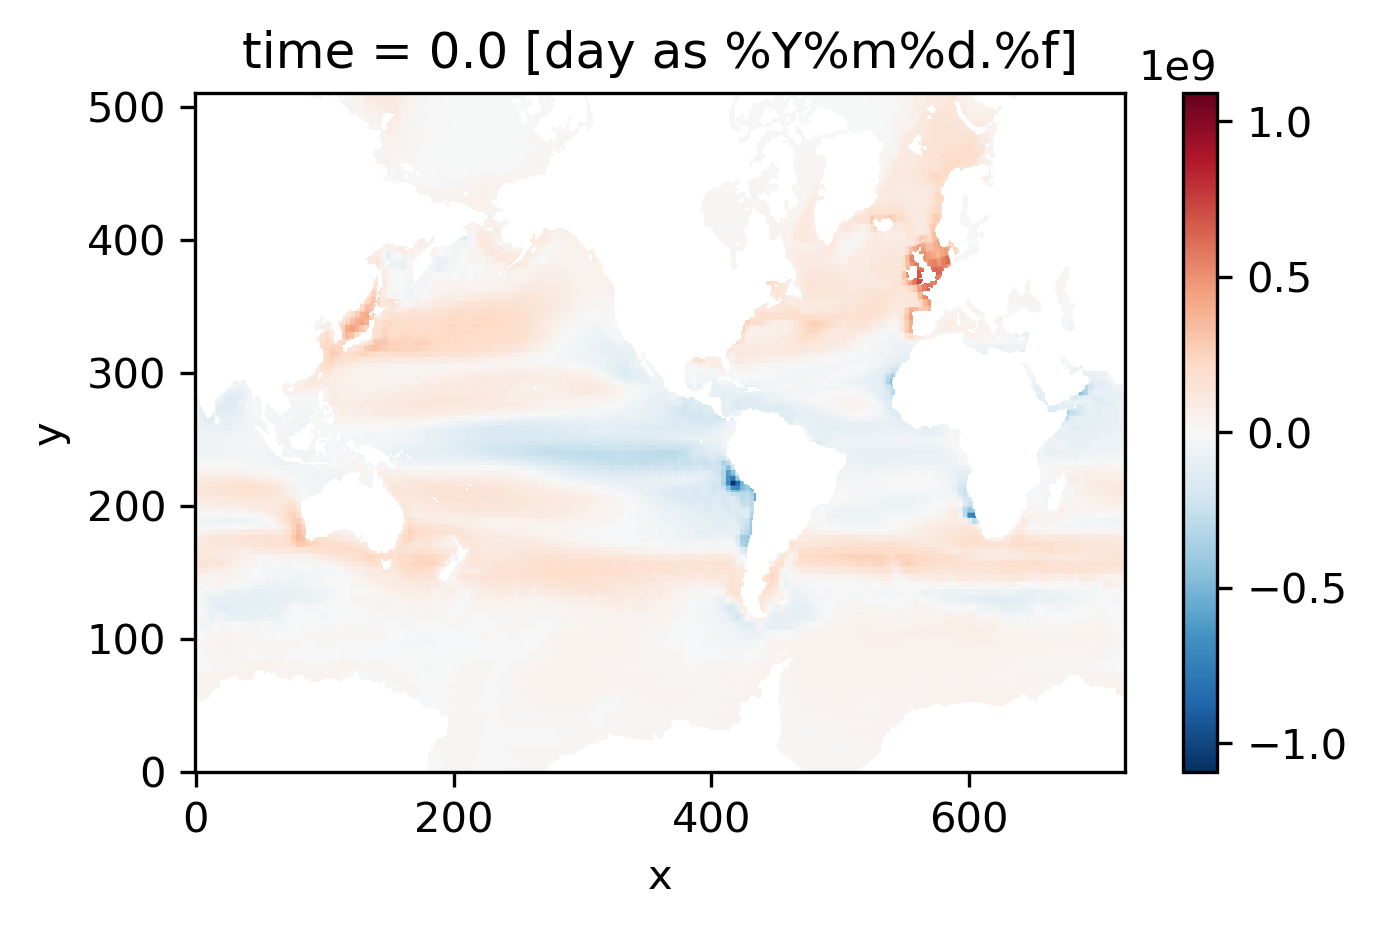

In [14]:
timmeanoflx = oflx.mean(dim='time_counter')
timmeanoflx.plot()

Text(0.5, 1.0, 'Time mean CO$2$ flux into the Ocean (SSP1-2.6) in GtCO2')

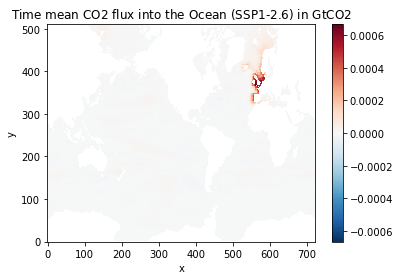

In [7]:
difflx = (oflx-bflx)*1e-12 #in GtCO2
difflxtimmean = difflx.mean(dim='time_counter')
difflxtimmean.plot()
plt.title('Time mean CO$2$ flux into the Ocean (SSP1-2.6) in GtCO2')

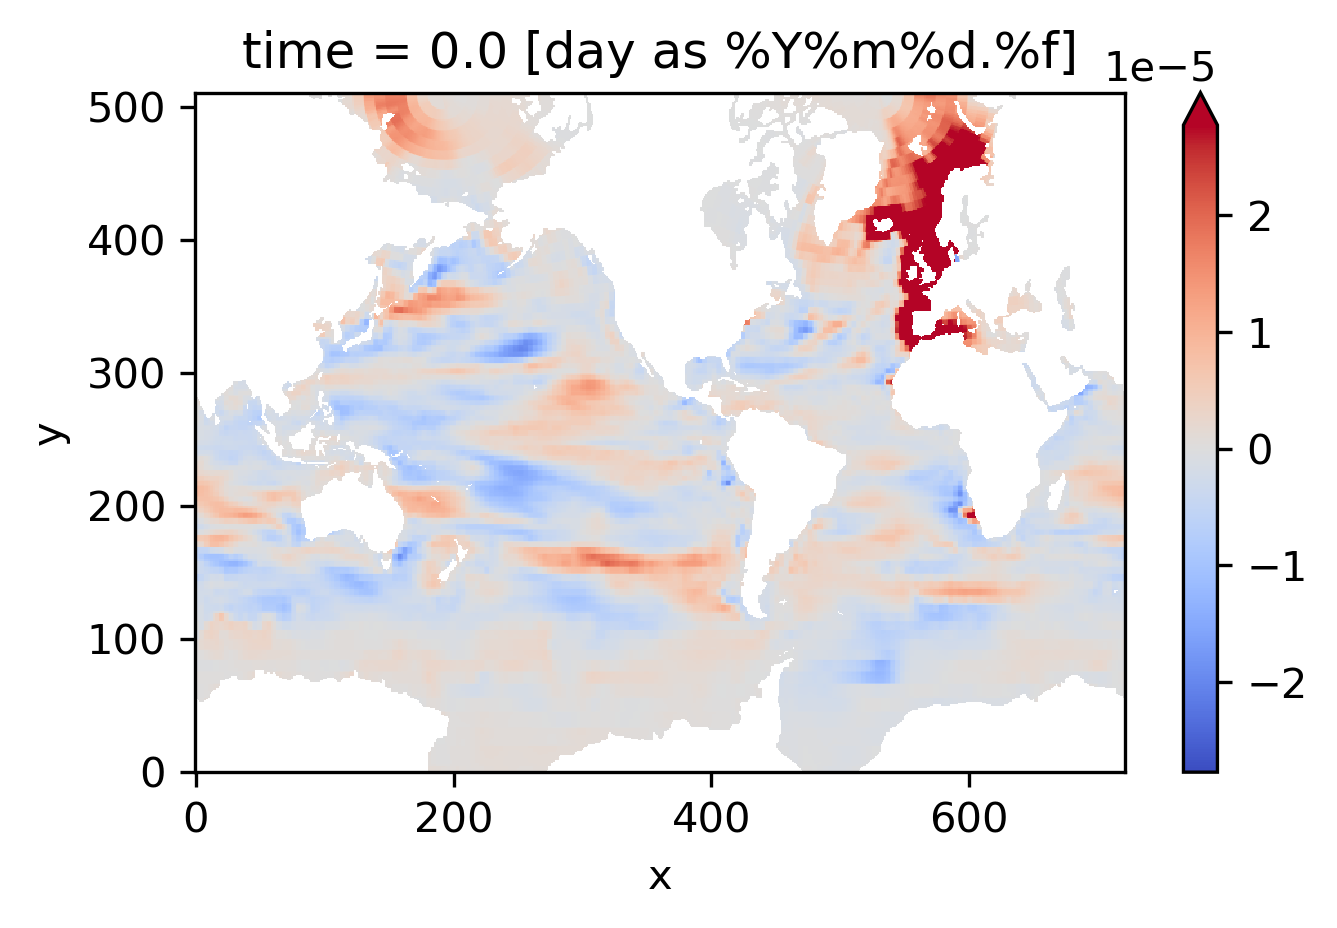

In [8]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams["figure.figsize"] = [5, 3]
difflx = (oflx-bflx)*1e-12 #in GtCO2
difflxtimmean = difflx.mean(dim='time_counter')
difflxtimmean.plot(robust=True,cmap='coolwarm')
# plt.title('Time mean CO$2$ flux difference into the Ocean (SSP3-7.0) in GtCO2')

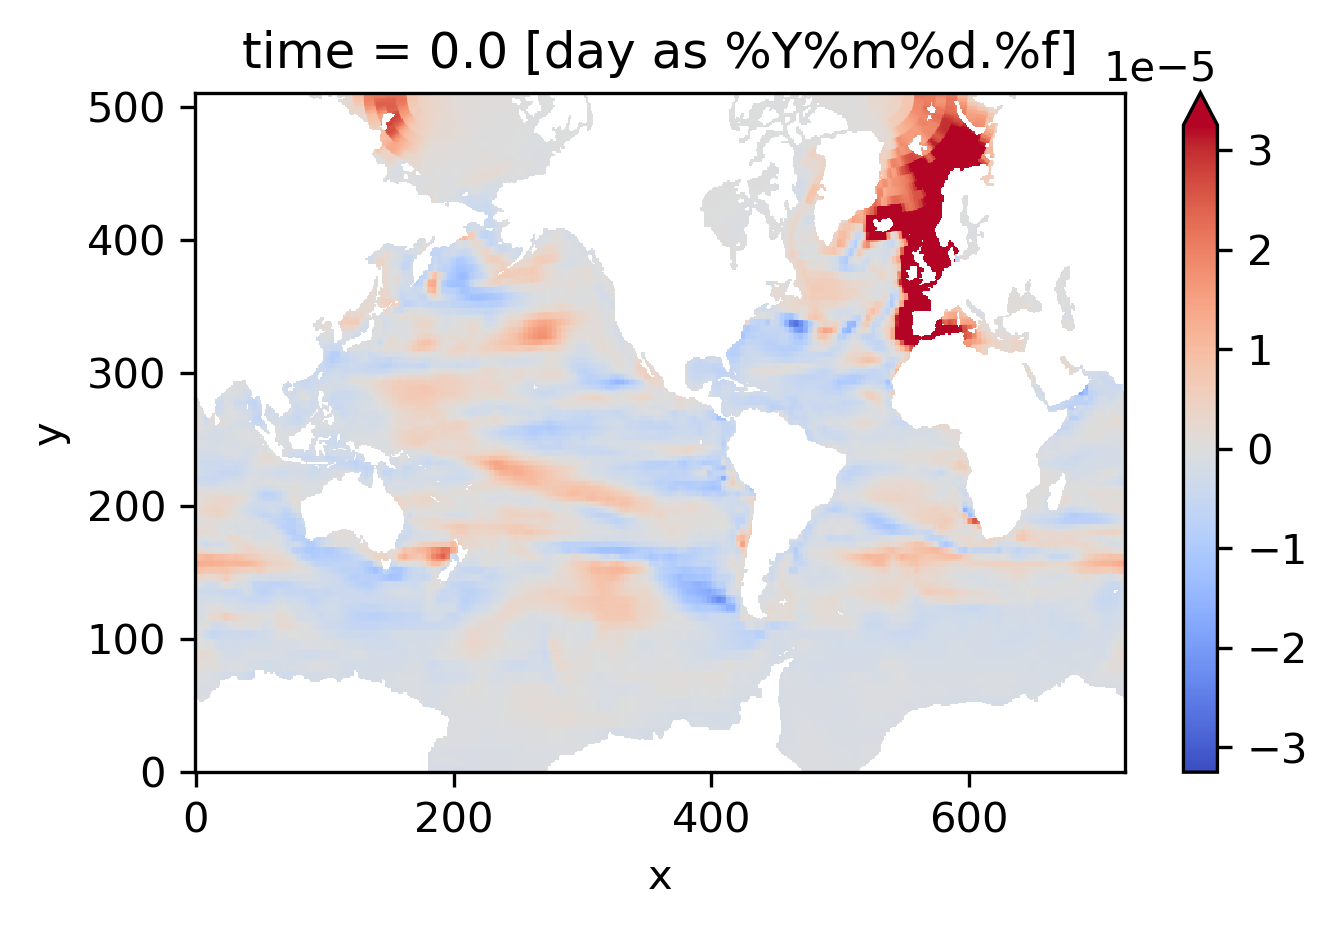

In [12]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams["figure.figsize"] = [5, 3]
difflx = (oflx-bflx)*1e-12 #in GtCO2
difflxtimmean = difflx.mean(dim='time_counter')
difflxtimmean.plot(robust=True,cmap='coolwarm')
# plt.title('Time mean CO$2$ flux difference(SSP1-2.6) in GtCO2')


In [13]:
val = difflxtimmean.max()
val.values

array(0.00066518)

In [8]:
#kgco2/m2/s to kgco2/yr region of alkalinity addition
oae_co2flux_region = -oae_co2flux*region_mask*31536000
base_co2flux_region = -base_co2flux*region_mask*31536000
orflx = oae_co2flux_region*grid_cell_area
brflx = base_co2flux_region*grid_cell_area
roae_flux = orflx.sum(['y','x'])
rbase_flux = brflx.sum(['y','x'])

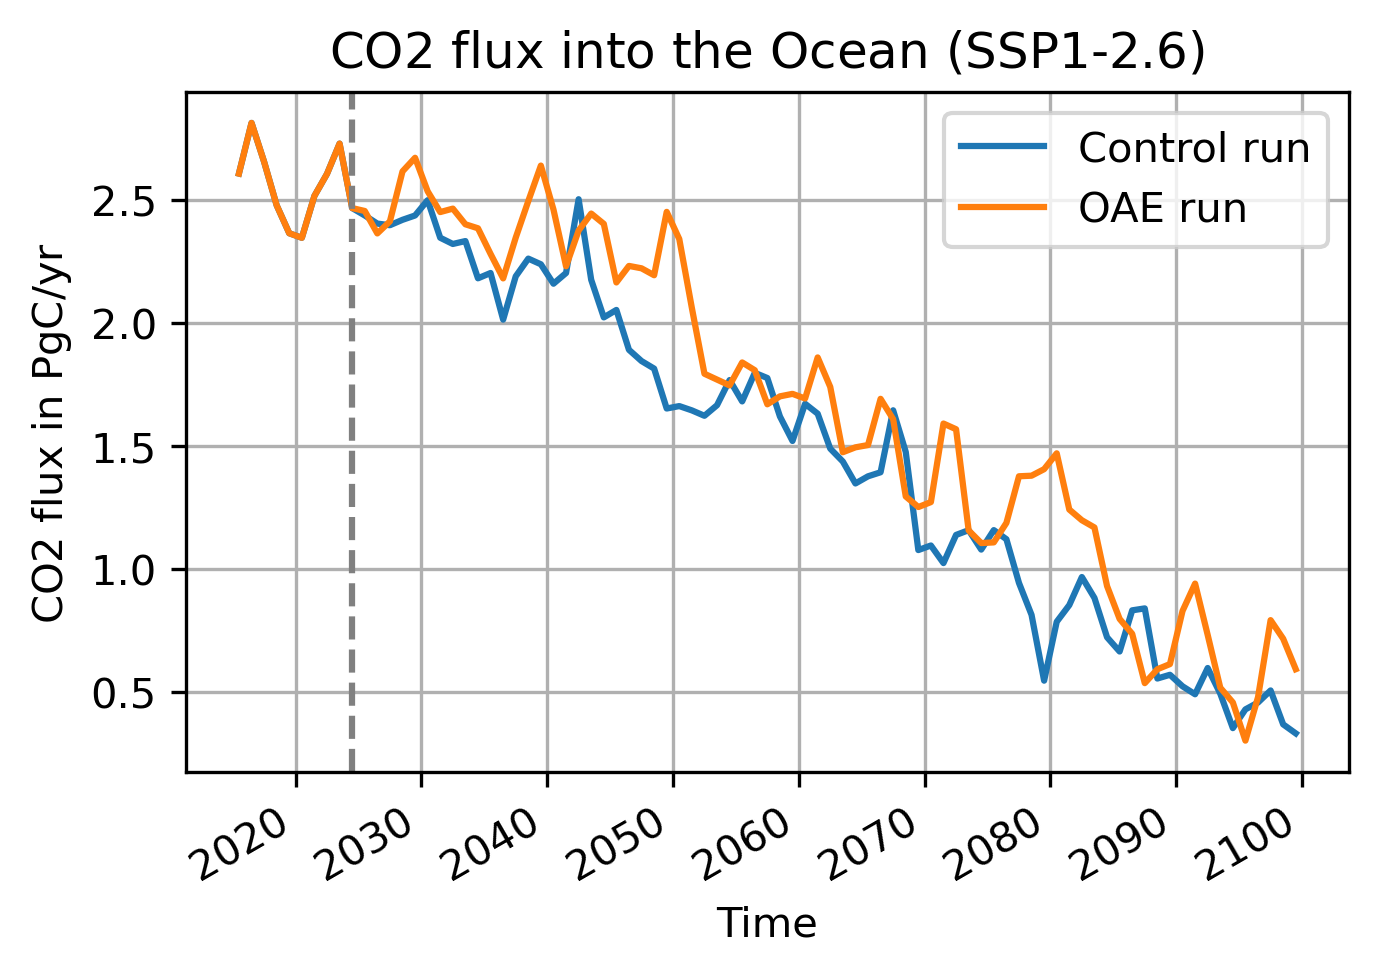

In [9]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams["figure.figsize"] = [5, 3]

# oae_flux_plot_region= roae_flux*1e-12
# base_flux_plot_region= rbase_flux*1e-12

oae_flux_plot= oae_flux*1e-12/3.664
base_flux_plot= base_flux*1e-12/3.664

base_flux_plot.plot(label='Control run')
oae_flux_plot.plot(label='OAE run')

# base_flux_plot_region.plot(label='base_region')
# oae_flux_plot_region.plot(label='oae_region')

plt.legend()
plt.title('CO$2$ flux into the Ocean (SSP1-2.6)') #CHANGE FOR SSP (SSP1-2.6) or (SSP3-7.0)
plt.ylabel('CO$2$ flux in PgC/yr')
plt.xlabel('Time')
plt.grid()
plt.axvline('2024-07-01T06:00:00.000000000',linestyle = '--',color='grey')

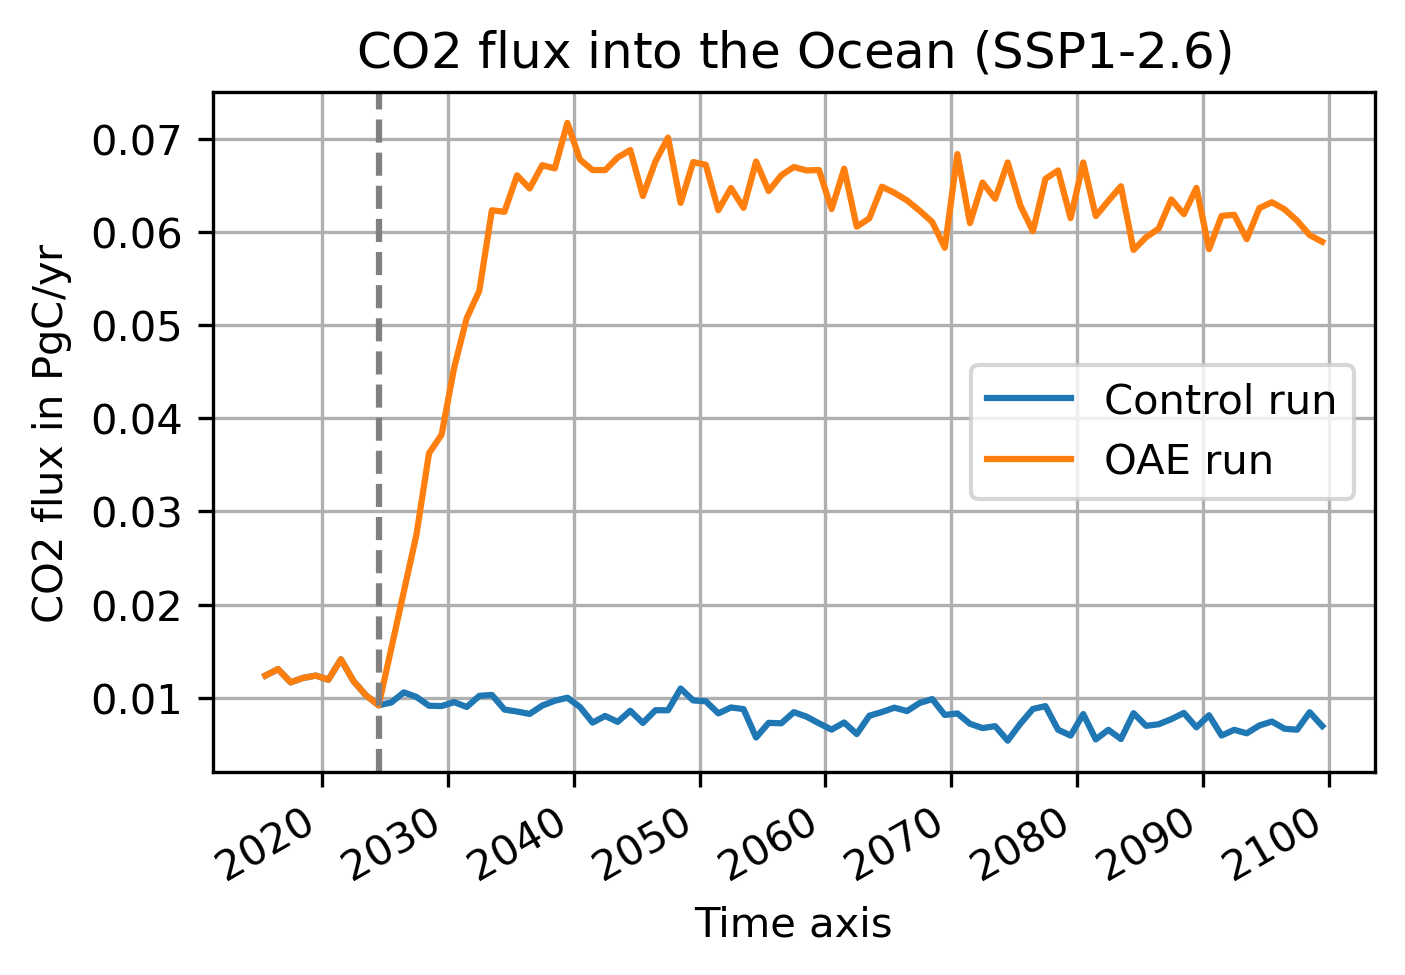

In [10]:
oae_flux_plot_region= roae_flux*1e-12/3.664
base_flux_plot_region= rbase_flux*1e-12/3.664

# oae_flux_plot= oae_flux*1e-12
# base_flux_plot= base_flux*1e-12

plt.rcParams['figure.dpi'] = 300
plt.rcParams["figure.figsize"] = [5, 3]



# base_flux_plot.plot(label='base_global')
# oae_flux_plot.plot(label='oae_global')

base_flux_plot_region.plot(label='Control run')
oae_flux_plot_region.plot(label='OAE run')

plt.legend()
plt.title('CO$2$ flux into the Ocean (SSP1-2.6)') #CHANGE FOR SSP (SSP1-2.6) (SSP3-7.0)
plt.ylabel('CO$2$ flux in PgC/yr')
plt.grid()
plt.axvline('2024-07-01T06:00:00.000000000',linestyle = '--',color='grey')

Text(0.5, 1.0, 'Region of alkalinity addition')

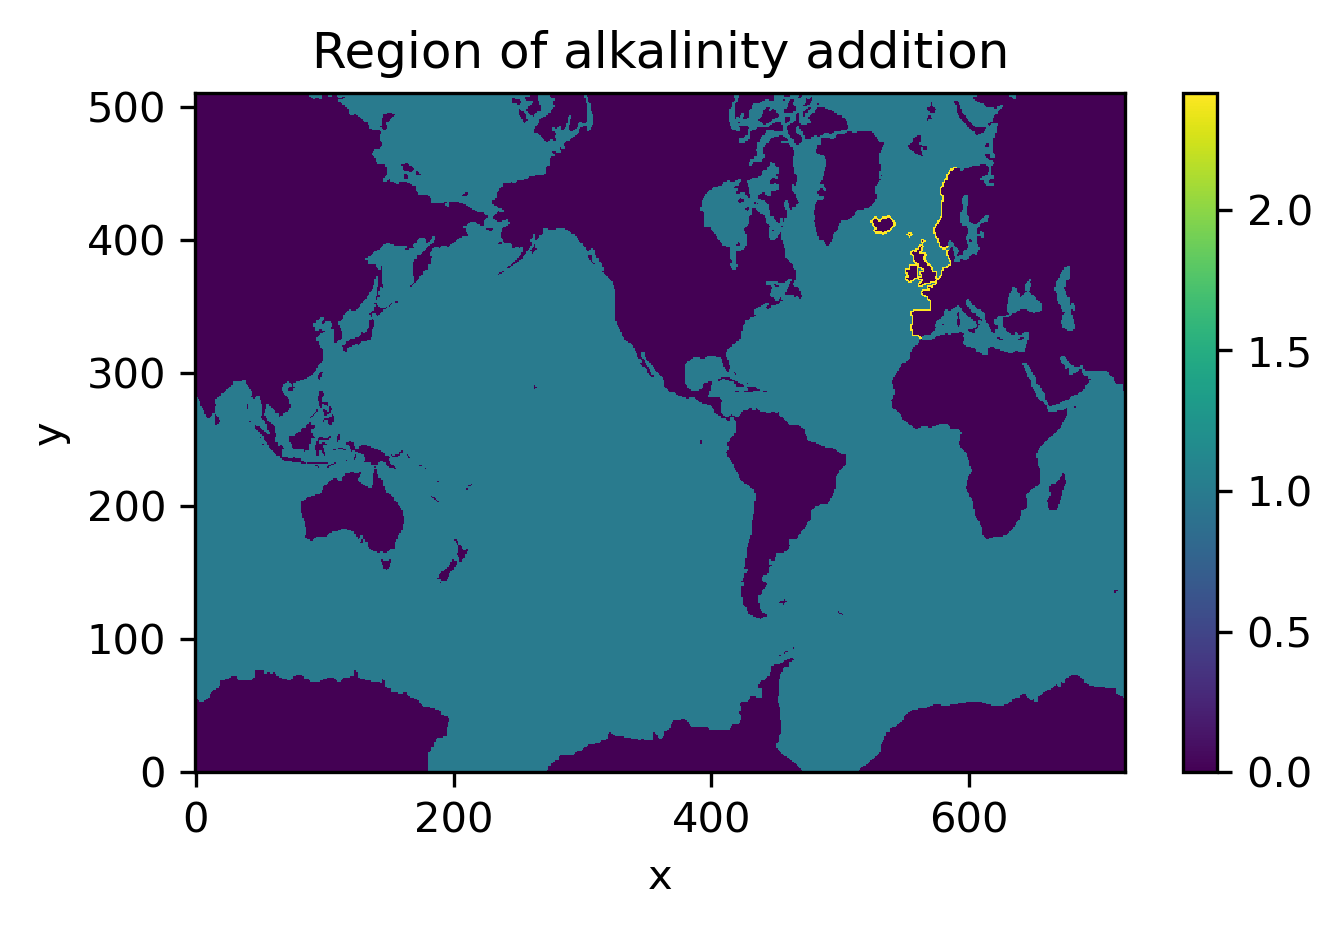

In [15]:
figure_alk_region = mesh_mask.tmask.isel(z=0,t=0)+alk
figure_alk_region.plot(size=3)
plt.title('Region of alkalinity addition')


In [54]:
figure_alk_region.nav_lon.values

array([[73.25      , 73.75      , 74.25      , ..., 71.75      ,
        72.25      , 72.75      ],
       [73.25      , 73.75      , 74.25      , ..., 71.75      ,
        72.25      , 72.75      ],
       [73.25      , 73.75      , 74.25      , ..., 71.75      ,
        72.25      , 72.75      ],
       ...,
       [73.01441956, 73.05451202, 73.08415222, ..., 72.91584778,
        72.94548798, 72.98558044],
       [73.00463867, 73.03128815, 73.04945374, ..., 72.95054626,
        72.96871185, 72.99536133],
       [73.00001526, 73.00985718, 73.01609039, ..., 72.98390961,
        72.99014282, 72.99998474]])

/home/shknmehe/miniconda3/envs/py3_std/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  """Entry point for launching an IPython kernel.


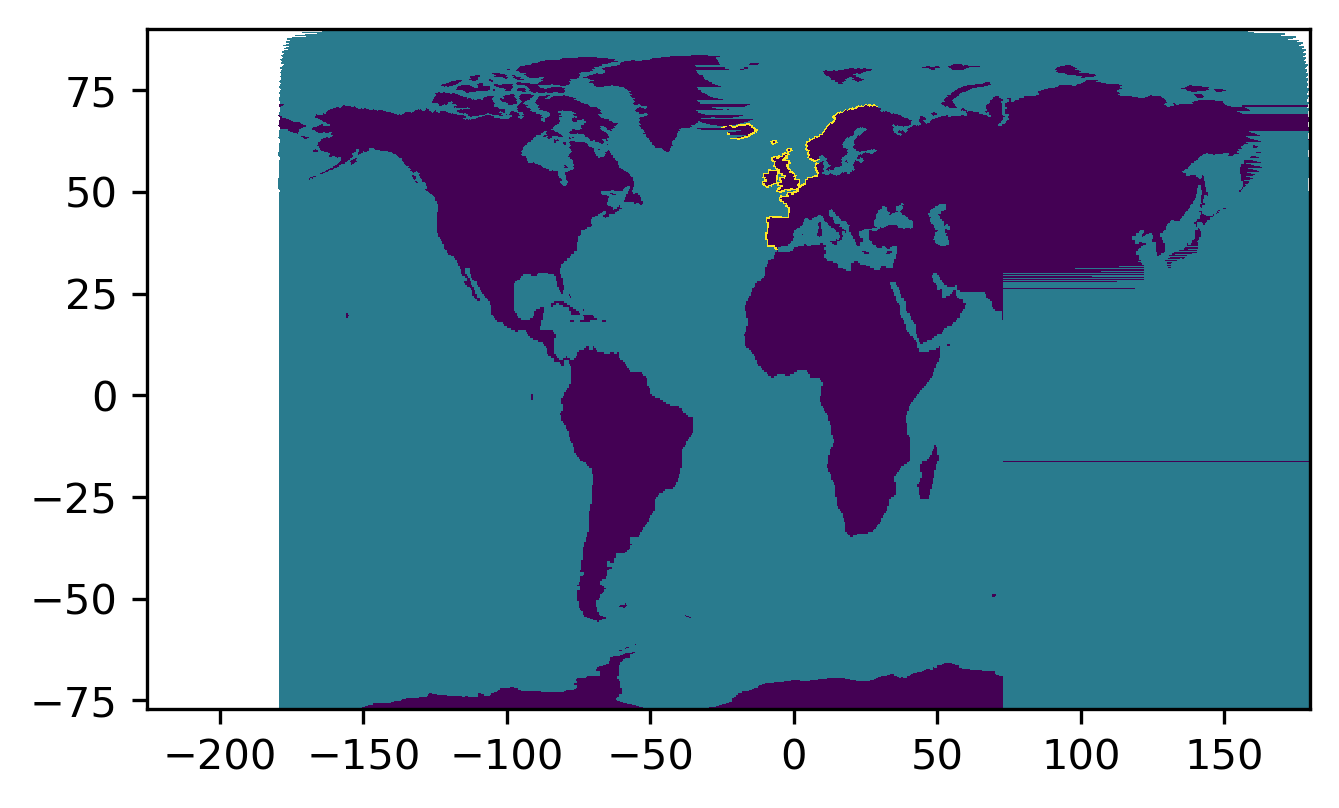

In [51]:
plt.pcolormesh(figure_alk_region.nav_lon,figure_alk_region.nav_lat,figure_alk_region)

In [19]:
fluxdiff = oae_flux_plot- base_flux_plot

fluxdiff

<xarray.DataArray (time_counter: 85)>
dask.array<sub, shape=(85,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 2015-07-01T06:00:00 ... 2099-...
    time          float64 0.0

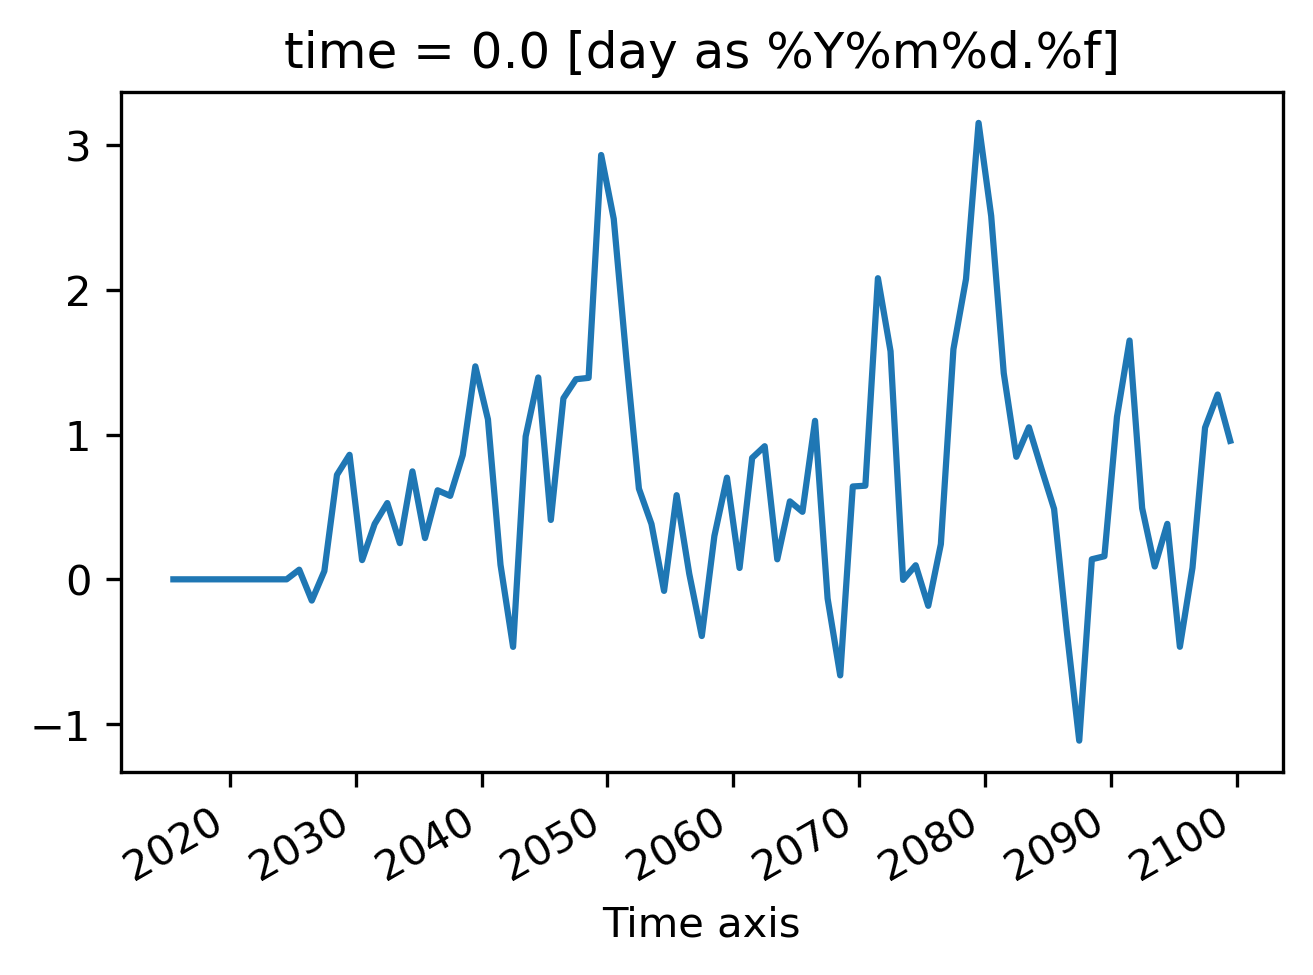

In [11]:
fluxdiff.plot()

In [20]:
np.sum(fluxdiff).values

array(17.83374768)

In [ ]:
65.3428515GtCO2 for ssp3-7.0

1 GtC = 3.664 billion tonnes CO2 = 3.664 GtCO2

In [61]:
65.3428515/3.664

17.833747680131

In [9]:
51.78/3.664

14.132096069868995

In [21]:
fluxdiffregion = oae_flux_plot_region-base_flux_plot_region
np.sum(fluxdiffregion).values

array(5.06728339)

In [11]:
fluxdiffregion = oae_flux_plot_region-base_flux_plot_region
np.sum(fluxdiffregion).values

array(3.97205443)